torch.Size([6, 3, 128, 128])


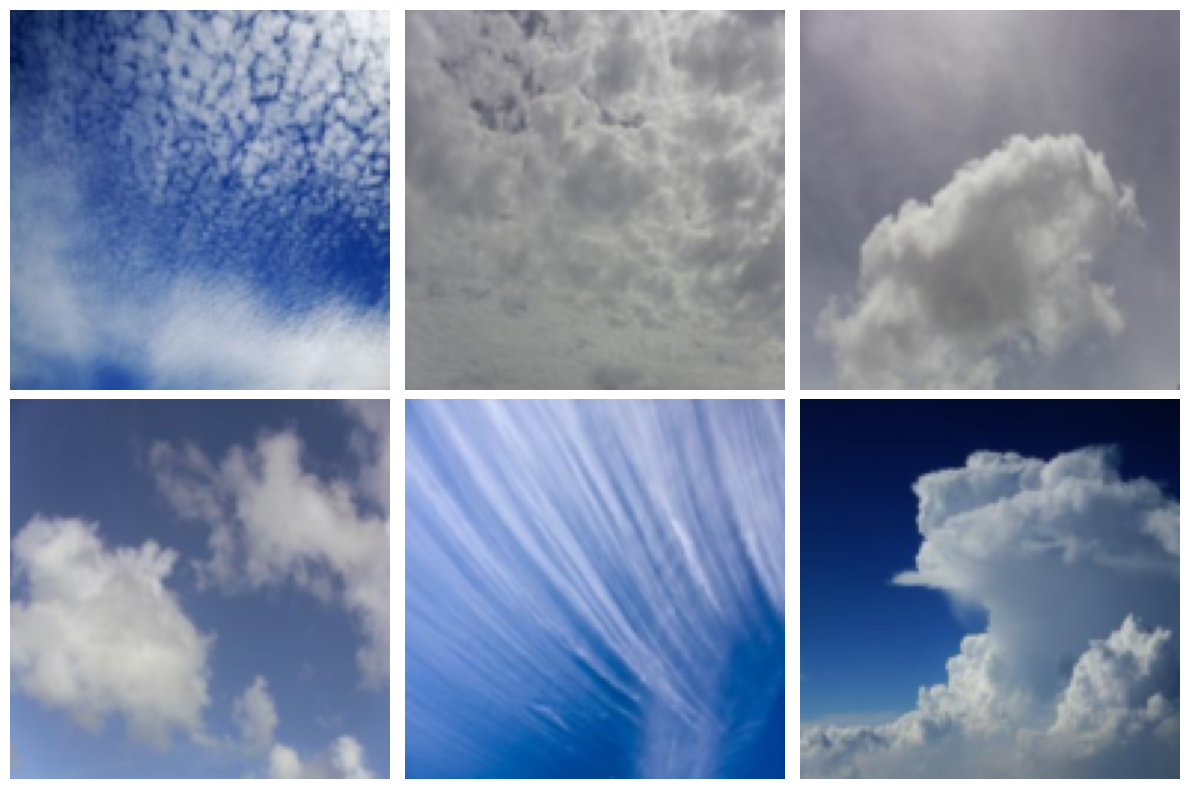

In [1]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils import data
import matplotlib.pyplot as plt

train_transforms = transforms.Compose([
  transforms.ToTensor(), # convert the object into a tensor
  transforms.Resize((128, 128)), # resize the images to be of size 128x128
])

dataset_train = ImageFolder(
  'clouds/clouds_train',
  transform=train_transforms,
)

dataloader_train = data.DataLoader(
  dataset_train,
  shuffle=True,
  batch_size=6,
)

images, labels = next(iter(dataloader_train))
print(images.shape)

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

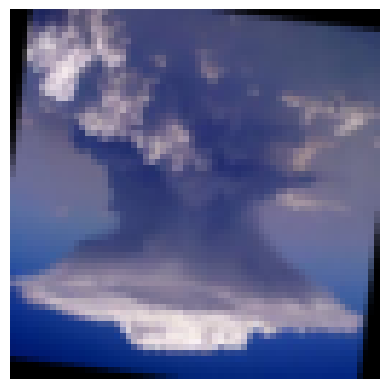

In [6]:
train_transforms = transforms.Compose([
  transforms.RandomHorizontalFlip(), # simulate different viewpoints of the sky
  transforms.RandomVerticalFlip(),
  transforms.RandomRotation(45), # expose model to different angles of cloud formations
  transforms.RandomAutocontrast(), # simulate different lighting conditions
  transforms.ToTensor(), # convert the object into a tensor
  transforms.Resize((64, 64)), # resize the images to be of size 128x128
])

dataset_train = ImageFolder(
  'clouds/clouds_train',
  transform=train_transforms,
)

dataloader_train = data.DataLoader(
    dataset_train,
    shuffle=True,
    batch_size=16,
)

images, labels = next(iter(dataloader_train))
image = images[0].permute(1, 2, 0)
plt.imshow(image)
plt.axis('off')
plt.show()



In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import torch
import numpy as np


def train_model(dataloader_train,
                dataloader_val,
                optimizer,
                net,
                num_epochs,
                create_plot=False):

    criterion = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(num_epochs):
        train_loss = 0
        val_loss = 0

        for features, labels in tqdm.tqdm(dataloader_train):
            optimizer.zero_grad()  # clear the gradients
            outputs = net(features)  # forward pass
            loss = criterion(outputs, labels)  # calculate the loss
            loss.backward()  # compute the gradients
            optimizer.step()  # tweak weights
            train_loss += loss.item()

        train_loss /= len(dataloader_train)

        with torch.no_grad():
            for features, labels in dataloader_val:
                outputs = net(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(dataloader_val)

        print(f"Average train and validation loss: {(train_loss, val_loss)}")
        loss_history.append((train_loss, val_loss))

    if create_plot:
        losses = np.array(loss_history)
        epochs = np.arange(num_epochs)

        plt.scatter(epochs, losses[:, 0], label="Train Loss")
        plt.scatter(epochs, losses[:, 1], label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss (Cross-Entropy)")
        plt.ylim(0, np.max(loss_history) * 1.05)
        plt.show()
    return loss_history

In [68]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Conv2d(in_channels=3,
                             out_channels=32,
                             kernel_size=3,
                             padding=1)
        self.fc2 = nn.ELU()
        self.fc3 = nn.MaxPool2d(kernel_size=2)

        self.fc4 = nn.Conv2d(in_channels=32,
                             out_channels=64,
                             kernel_size=3,
                             padding=1)
        self.fc5 = nn.ELU()
        self.fc6 = nn.MaxPool2d(kernel_size=2)
        self.fc7 = nn.Linear(16 * 16 * 64, 7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        x = self.fc5(x)
        x = self.fc6(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc7(x)
        #Not needed because Cross entropy does it internally
        # x = F.softmax(x, dim=1)

        return x

In [69]:
images, labels = next(iter(dataloader_train))
image = images[0]
label = labels[0]

print(label.item())

3


In [70]:
from sklearn.model_selection import train_test_split

#Stratified split:

labels = [sample[1] for sample in dataset_train.samples]
indices = np.arange(len(dataset_train))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = data.Subset(dataset_train, train_idx)
val_dataset = data.Subset(dataset_train, val_idx)




100%|██████████| 24/24 [00:00<00:00, 26.25it/s]


Average train and validation loss: (2.0155009229977927, 2.045422315597534)


100%|██████████| 24/24 [00:00<00:00, 25.58it/s]


Average train and validation loss: (1.8716618567705154, 1.7094573378562927)


100%|██████████| 24/24 [00:00<00:00, 25.04it/s]


...

Average train and validation loss: (1.1189032196998596, 1.4224666357040405)


100%|██████████| 24/24 [00:00<00:00, 28.36it/s]


Average train and validation loss: (1.2624896143873532, 1.098988761504491)


100%|██████████| 24/24 [00:01<00:00, 20.98it/s]


Average train and validation loss: (1.1352784459789593, 1.0881013174851735)


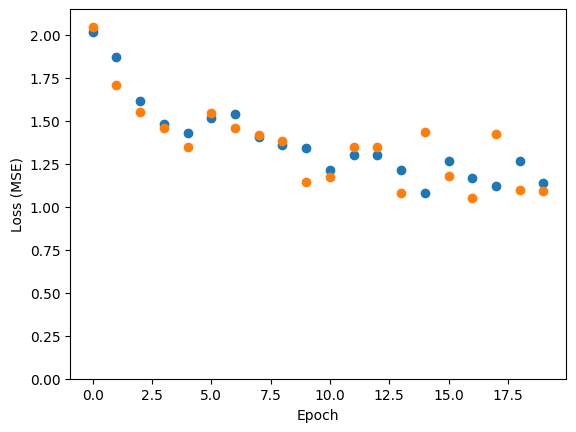

[(2.0155009229977927, 2.045422315597534),
 (1.8716618567705154, 1.7094573378562927),
 (1.6166851421197255, 1.5507602294286091),
 (1.478745440642039, 1.4564857681592305),
 (1.4270412971576054, 1.3479884664217632),
 (1.5156433532635372, 1.5429045756657918),
 (1.5370992744962375, 1.4590778549512227),
 (1.4018716514110565, 1.4164028565088909),
 (1.356907735268275, 1.3792158365249634),
 (1.3435516506433487, 1.141646186510722),
 (1.211382823685805, 1.1734714806079865),
 (1.299516628185908, 1.3464905222256978),
 (1.2993454113602638, 1.3483059008916218),
 (1.2123062958319981, 1.0791799624760945),
 (1.0794083053867023, 1.4347421526908875),
 (1.26253192871809, 1.1774811844031017),
 (1.167387031018734, 1.0493537584940593),
 (1.1189032196998596, 1.4224666357040405),
 (1.2624896143873532, 1.098988761504491),
 (1.1352784459789593, 1.0881013174851735)]

In [71]:
import torch.optim as optim

batch_size = 16
train_loader = data.DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=16, shuffle=False)
net = Net()
learning_rate = 0.001
optimizer = optim.AdamW(net.parameters(), lr = learning_rate)


train_model(train_loader, val_loader, optimizer, net, 20, True)


100%|██████████| 24/24 [00:01<00:00, 21.11it/s]


Average train and validation loss: (0.8517124255498251, 0.963772306839625)


100%|██████████| 24/24 [00:01<00:00, 18.97it/s]


Average train and validation loss: (0.8531746019919714, 0.8721238672733307)


100%|██████████| 24/24 [00:01<00:00, 23.05it/s]


...

Average train and validation loss: (0.7898401767015457, 0.8542008548974991)


100%|██████████| 24/24 [00:01<00:00, 19.41it/s]


Average train and validation loss: (0.6967282630503178, 0.8692107001940409)


100%|██████████| 24/24 [00:01<00:00, 19.48it/s]


Average train and validation loss: (0.6792214823265871, 0.814773291349411)


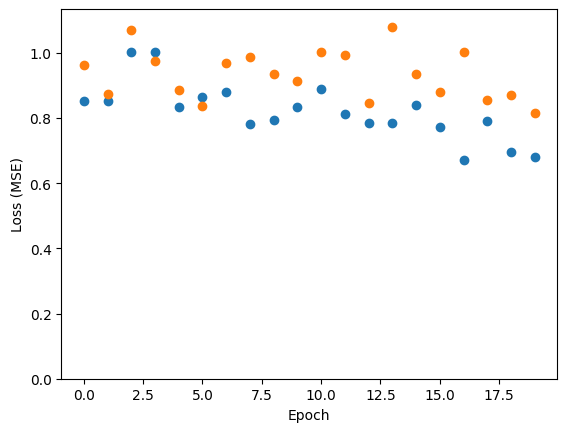

In [76]:
import time
import pprint

start_time = time.time()
train_model(train_loader, val_loader, optimizer, net, 20, True)
end_time = time.time()

total_time_taken = end_time - start_time
net.eval()

all_preds = []
all_labels = []

test_transforms = transforms.Compose([
  transforms.ToTensor(), # convert the object into a tensor
  transforms.Resize((64, 64)), # resize the images to be of size 128x128
])

dataset_test = ImageFolder(
  'clouds/clouds_test',
  transform=test_transforms,
)

dataloader_test = data.DataLoader(
  dataset_test,
  shuffle=True,
  batch_size=16,
)

with torch.no_grad():
    for features, labels in dataloader_test:
        outputs = net(features)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)


In [77]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1 = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print(f"Summary statistics:")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"Total time taken to train the model in seconds: {total_time_taken}")

f1_per_class = f1_score(all_labels, all_preds, average=None)
class_names = [
    "cirriform clouds", "clear sky", "cumulonimbus clouds", "cumulus clouds",
    "high cumuliform clouds", "stratiform clouds", "stratocumulus clouds"
]

f1_dict = dict(zip(class_names, f1_per_class))

pprint.pprint(f1_dict)

Summary statistics:
Precision: 0.6534941475385576
Recall: 0.6785037654160158
F1: 0.6469977196636493
Total time taken to train the model in seconds: 28.162805318832397
{'cirriform clouds': 0.5203252032520326,
 'clear sky': 0.9014084507042254,
 'cumulonimbus clouds': 0.4,
 'cumulus clouds': 0.6794258373205742,
 'high cumuliform clouds': 0.6381322957198443,
 'stratiform clouds': 0.8735632183908046,
 'stratocumulus clouds': 0.5161290322580645}


In [80]:
class VGGNet(nn.Module):

    def __init__(self):
        super(VGGNet, self).__init__()
        self.fc1 = nn.Conv2d(in_channels=3,
                             out_channels=64,
                             kernel_size=3,
                             padding=1)
        self.fc2 = nn.Conv2d(in_channels=64,
                             out_channels=64,
                             kernel_size=3,
                             padding=1)
        self.fc3 = nn.MaxPool2d(kernel_size=2)

        self.fc4 = nn.Conv2d(in_channels=64,
                             out_channels=128,
                             kernel_size=3,
                             padding=1)

        self.fc5 = nn.Conv2d(in_channels=128,
                             out_channels=128,
                             kernel_size=3,
                             padding=1)

        self.fc6 = nn.MaxPool2d(kernel_size=2)

        self.fc7 = nn.Conv2d(in_channels=128,
                             out_channels=256,
                             kernel_size=3,
                             padding=1)

        self.fc8 = nn.Conv2d(in_channels=256,
                             out_channels=256,
                             kernel_size=3,
                             padding=1)

        self.fc9 = nn.Conv2d(in_channels=256,
                             out_channels=256,
                             kernel_size=3,
                             padding=1)

        self.fc10 = nn.MaxPool2d(kernel_size=2)

        self.fc11 = nn.Conv2d(in_channels=256,
                              out_channels=512,
                              kernel_size=3,
                              padding=1)

        self.fc12 = nn.Conv2d(in_channels=512,
                              out_channels=512,
                              kernel_size=3,
                              padding=1)

        self.fc13 = nn.Conv2d(in_channels=512,
                              out_channels=512,
                              kernel_size=3,
                              padding=1)

        self.fc14 = nn.MaxPool2d(kernel_size=2)

        self.fc15 = nn.Conv2d(in_channels=512,
                              out_channels=512,
                              kernel_size=3,
                              padding=1)

        self.fc16 = nn.Conv2d(in_channels=512,
                              out_channels=512,
                              kernel_size=3,
                              padding=1)

        self.fc17 = nn.Conv2d(in_channels=512,
                              out_channels=512,
                              kernel_size=3,
                              padding=1)

        self.fc18 = nn.MaxPool2d(kernel_size=2)

        #because input is 64x64 and not 224x224
        self.fc19 = nn.Linear(2 * 2 * 512, 2 * 2 * 512)
        self.fc20 = nn.Linear(2 * 2 * 512, 7)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        x = self.fc5(x)
        x = self.fc6(x)
        x = self.fc7(x)
        x = self.fc8(x)
        x = self.fc9(x)
        x = self.fc10(x)
        x = self.fc11(x)
        x = self.fc12(x)
        x = self.fc13(x)
        x = self.fc14(x)
        x = self.fc15(x)
        x = self.fc16(x)
        x = self.fc17(x)
        x = self.fc18(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc19(x)
        x = self.fc20(x)
        #Not needed because Cross entropy does it internally
        # x = F.softmax(x, dim=1)

        return x

100%|██████████| 24/24 [00:01<00:00, 22.26it/s]


Average train and validation loss: (0.9116054760913054, 0.9397929906845093)


100%|██████████| 24/24 [00:01<00:00, 20.79it/s]


Average train and validation loss: (0.7138302860160669, 0.956833134094874)


100%|██████████| 24/24 [00:01<00:00, 20.66it/s]


...

Average train and validation loss: (0.7675215726097425, 0.9443563520908356)


100%|██████████| 24/24 [00:00<00:00, 25.67it/s]


Average train and validation loss: (0.7262999235341946, 0.965927558640639)


100%|██████████| 24/24 [00:01<00:00, 18.28it/s]


Average train and validation loss: (0.642828069627285, 0.7964325944582621)


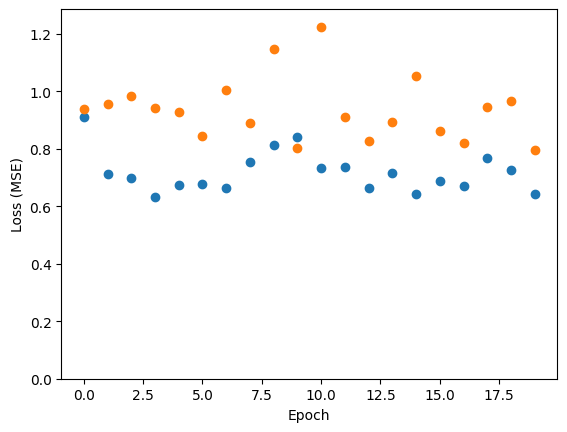

Total time taken to train the model in seconds: 28.626059770584106


In [81]:
batch_size = 16
train_loader = data.DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=16, shuffle=False)
vggnet = VGGNet()
learning_rate = 0.001
optimizer = optim.AdamW(net.parameters(), lr = learning_rate)

start_time = time.time()
train_model(train_loader, val_loader, optimizer, net, 20, True)
end_time = time.time()

total_time_taken = end_time - start_time
print(f"Total time taken to train the model in seconds: {total_time_taken}")


In [82]:
net.eval()

all_preds = []
all_labels = []

test_transforms = transforms.Compose([
  transforms.ToTensor(), # convert the object into a tensor
  transforms.Resize((64, 64)), # resize the images to be of size 128x128
])

dataset_test = ImageFolder(
  'clouds/clouds_test',
  transform=test_transforms,
)

dataloader_test = data.DataLoader(
  dataset_test,
  shuffle=True,
  batch_size=16,
)

with torch.no_grad():
    for features, labels in dataloader_test:
        outputs = net(features)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

f1 = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print(f"Summary statistics:")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"Total time taken to train the model in seconds: {total_time_taken}")

f1_per_class = f1_score(all_labels, all_preds, average=None)
class_names = [
    "cirriform clouds", "clear sky", "cumulonimbus clouds", "cumulus clouds",
    "high cumuliform clouds", "stratiform clouds", "stratocumulus clouds"
]

f1_dict = dict(zip(class_names, f1_per_class))

pprint.pprint(f1_dict)

Summary statistics:
Precision: 0.7138617748126188
Recall: 0.7454367380257674
F1: 0.723838863108985
Total time taken to train the model in seconds: 28.626059770584106
{'cirriform clouds': 0.6289308176100629,
 'clear sky': 0.9014084507042254,
 'cumulonimbus clouds': 0.46153846153846156,
 'cumulus clouds': 0.7489711934156379,
 'high cumuliform clouds': 0.6779661016949152,
 'stratiform clouds': 0.9156626506024096,
 'stratocumulus clouds': 0.7323943661971831}


This model performs much better even with less training. Let's try to train it for more epochs.

100%|██████████| 24/24 [00:01<00:00, 21.46it/s]


Average train and validation loss: (0.6119711939245462, 0.9548860589663187)


100%|██████████| 24/24 [00:00<00:00, 24.21it/s]


Average train and validation loss: (0.6402428063253561, 0.9796234468619028)


100%|██████████| 24/24 [00:01<00:00, 21.23it/s]


...

Average train and validation loss: (0.3865773193538189, 1.0993642161289852)


100%|██████████| 24/24 [00:01<00:00, 23.93it/s]


Average train and validation loss: (0.36698431707918644, 1.3135493695735931)


100%|██████████| 24/24 [00:00<00:00, 24.38it/s]


Average train and validation loss: (0.34964367592086393, 1.1331302225589752)


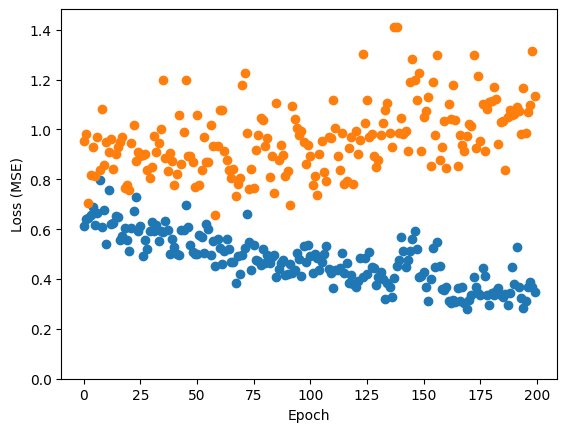

Total time taken to train the model in seconds: 284.88117384910583


In [83]:
start_time = time.time()
train_model(train_loader, val_loader, optimizer, net, 200, True)
end_time = time.time()

total_time_taken = end_time - start_time
print(f"Total time taken to train the model in seconds: {total_time_taken}")


In [84]:
net.eval()

all_preds = []
all_labels = []

test_transforms = transforms.Compose([
  transforms.ToTensor(), # convert the object into a tensor
  transforms.Resize((64, 64)), # resize the images to be of size 128x128
])

dataset_test = ImageFolder(
  'clouds/clouds_test',
  transform=test_transforms,
)

dataloader_test = data.DataLoader(
  dataset_test,
  shuffle=True,
  batch_size=16,
)

with torch.no_grad():
    for features, labels in dataloader_test:
        outputs = net(features)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

f1 = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print(f"Summary statistics:")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"Total time taken to train the model in seconds: {total_time_taken}")

f1_per_class = f1_score(all_labels, all_preds, average=None)
class_names = [
    "cirriform clouds", "clear sky", "cumulonimbus clouds", "cumulus clouds",
    "high cumuliform clouds", "stratiform clouds", "stratocumulus clouds"
]

f1_dict = dict(zip(class_names, f1_per_class))

pprint.pprint(f1_dict)

Summary statistics:
Precision: 0.7118624656713806
Recall: 0.7586098413390443
F1: 0.7189026300742439
Total time taken to train the model in seconds: 284.88117384910583
{'cirriform clouds': 0.6424242424242425,
 'clear sky': 0.9402985074626866,
 'cumulonimbus clouds': 0.5142857142857142,
 'cumulus clouds': 0.7531380753138075,
 'high cumuliform clouds': 0.693069306930693,
 'stratiform clouds': 0.925,
 'stratocumulus clouds': 0.5641025641025641}


We can clearly see that the model is overfitting on the train data. Let's try to do some hyperparameter tuning.

In [91]:
def train_model(dataloader_train,
                dataloader_val,
                optimizer,
                net,
                num_epochs,
                create_plot=False):

    criterion = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(num_epochs):
        train_loss = 0
        val_loss = 0

        for features, labels in dataloader_train:
            optimizer.zero_grad()  # clear the gradients
            outputs = net(features)  # forward pass
            loss = criterion(outputs, labels)  # calculate the loss
            loss.backward()  # compute the gradients
            optimizer.step()  # tweak weights
            train_loss += loss.item()

        train_loss /= len(dataloader_train)

        with torch.no_grad():
            for features, labels in dataloader_val:
                outputs = net(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(dataloader_val)

        loss_history.append((train_loss, val_loss))

    if create_plot:
        losses = np.array(loss_history)
        epochs = np.arange(num_epochs)

        plt.scatter(epochs, losses[:, 0], label="Train Loss")
        plt.scatter(epochs, losses[:, 1], label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss (Cross-Entropy)")
        plt.ylim(0, np.max(loss_history) * 1.05)
        plt.show()
    return loss_history

In [94]:
from torchmetrics import F1Score

results = []

best_model = None

dataloader_train = train_loader
dataloader_val = val_loader

learning_rates = np.logspace(-6, -1, 10)
num_epochs = 50

nettypes = [Net, VGGNet]

for nettype in nettypes:
    for learning_rate in tqdm.tqdm(learning_rates):
        net = nettype()
        optimizer = optim.AdamW(net.parameters(), lr = learning_rate)
        loss_history = train_model(dataloader_train, dataloader_val,optimizer, net, num_epochs)

        f1 = F1Score(task='multiclass', num_classes=7)
        net.eval()

        with torch.no_grad():
            for features, labels in dataloader_test:
                outputs = net(features)
                preds = torch.argmax(outputs, dim=1)
                f1(preds, labels)

        f1 = f1.compute()
        print(f'F1" {f1}')

        results.append({
            "learning_rate": learning_rate,
            "final_train_loss": loss_history[-1][0],
            "final_val_loss": loss_history[-1][1],
            "f1_score": f1.item()
        })

        if best_model == None or f1.item() > best_model['f1_score']:
            best_model = ({
                "learning_rate": learning_rate,
                "final_train_loss": loss_history[-1][0],
                "final_val_loss": loss_history[-1][1],
                "f1_score": f1.item()
            })

 10%|█         | 1/10 [01:11<10:41, 71.30s/it]

F1" 0.2119341492652893


 20%|██        | 2/10 [02:25<09:42, 72.78s/it]

F1" 0.23045267164707184


 30%|███       | 3/10 [03:30<08:06, 69.49s/it]

...

F1" 0.3395061790943146


 90%|█████████ | 9/10 [1:41:14<11:20, 680.85s/it]

F1" 0.3230452537536621


100%|██████████| 10/10 [1:52:44<00:00, 676.49s/it]

F1" 0.2119341492652893


In [96]:
import pandas as pd
df = pd.DataFrame(results)
df.to_excel("model_report.xlsx", index=False)

